## 11.04节练习参考答案

## 环境准备

In [ ]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

import numpy as np
import matplotlib.pyplot as plt
import torch
import math

from src.utils import train_2d, show_trace_2d, show_trace

本节的解答思路参考了 [《动手学深度学习》习题解答](https://datawhalechina.github.io/d2l-ai-solutions-manual/#/ch11/ch11)。

### 练习11.4.1
尝试不同的随机梯度下降学习率计划和不同的迭代次数进行实验。特别是，根据迭代次数的函数来绘制与最优解$(0, 0)$的距离。

**解答：**

epoch 50, x1: 0.055758, x2: 0.093267


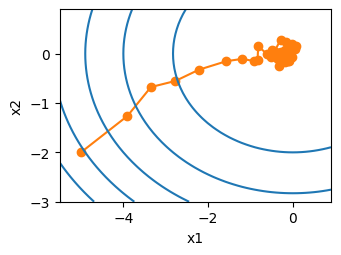

In [2]:
def f(x1, x2):  # 目标函数
    return x1 ** 2 + 2 * x2 ** 2

def f_grad(x1, x2):  # 目标函数的梯度
    return 2 * x1, 4 * x2

def sgd(x1, x2, s1, s2, f_grad):
    g1, g2 = f_grad(x1, x2)
    # 模拟有噪声的梯度
    g1 += torch.normal(0.0, 1, (1,)).item()
    g2 += torch.normal(0.0, 1, (1,)).item()
    eta_t = eta * lr()
    return (x1 - eta_t * g1, x2 - eta_t * g2, 0, 0)

def constant_lr():
    return 1

eta = 0.1
lr = constant_lr  # 常数学习速度
show_trace_2d(f, train_2d(sgd, steps=50, f_grad=f_grad))

epoch 1000, x1: -0.770189, x2: -0.072966


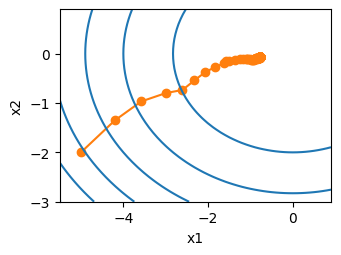

In [3]:
def exponential_lr():
    # 在函数外部定义，而在内部更新的全局变量
    global t
    t += 1
    return math.exp(-0.1 * t)

t = 1
lr = exponential_lr
show_trace_2d(f, train_2d(sgd, steps=1000, f_grad=f_grad))

epoch 50, x1: -0.057338, x2: -0.091549


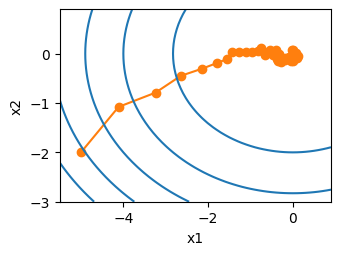

In [4]:
def polynomial_lr():
    # 在函数外部定义，而在内部更新的全局变量
    global t
    t += 1
    return (1 + 0.1 * t) ** (-0.5)

t = 1
lr = polynomial_lr
show_trace_2d(f, train_2d(sgd, steps=50, f_grad=f_grad))

### 练习11.4.2
证明对于函数$f(x_1, x_2) = x_1^2 + 2 x_2^2$而言，向梯度添加正态噪声等同于最小化损失函数$f(\mathbf{x}, \mathbf{w}) = (x_1 - w_1)^2 + 2 (x_2 - w_2)^2$，其中$\mathbf{x}$是从正态分布中提取的。

**解答：**

设当前参数 $\boldsymbol{w}$，$f(\boldsymbol{w})=w_1^2+2w_2^2$，$\nabla f(\boldsymbol{w})=(2w_1,4w_2)$。加零均值高斯噪声 $\boldsymbol{n}\sim\mathcal{N}(\boldsymbol{0},\Sigma)$ 得随机梯度 $\boldsymbol{g}=\nabla f(\boldsymbol{w})+\boldsymbol{n}$，$\mathbb{E}[\boldsymbol{g}]=\nabla f(\boldsymbol{w})$。

另一方面，单样本损失 $\ell(\boldsymbol{w};\boldsymbol{x})=(x_1-w_1)^2+2(x_2-w_2)^2$ 的随机梯度为

$$\nabla_{\boldsymbol{w}}\ell=\big(-2(x_1-w_1),\,-4(x_2-w_2)\big)=(2w_1,4w_2)+(-2x_1,-4x_2)=\nabla f(\boldsymbol{w})+\boldsymbol{n}',$$

其中 $\boldsymbol{n}'=(-2x_1,-4x_2)$。当 $\boldsymbol{x}$ 服从零均值高斯时 $\boldsymbol{n}'$ 也是零均值高斯。只要 $\boldsymbol{x}$ 的协方差使 $\boldsymbol{n}'$ 与 $\boldsymbol{n}$ 同分布，两种随机梯度同分布，“向 $\nabla f$ 加噪声”与“用单样本估计 $\ell$”等价。

### 练习11.4.3
从$\{(x_1, y_1), \ldots, (x_n, y_n)\}$分别使用替换方法以及不替换方法进行采样时，比较随机梯度下降的收敛性。

**解答：**

两者都收敛，但**不放回采样**通常**不慢于**有放回采样。一个 epoch 内不放回采样保证每个样本恰好使用一次，梯度估计更均匀；理论上不放回 SGD 的收敛速率不差于（在适当条件下优于）有放回情形（Recht et al., 2012 及后续工作）。有放回采样便于独立性分析，但单 epoch 内可能重复抽取某些样本、遗漏另一些，信息利用率偏低。因此实际训练普遍采用不放回的 epoch 遍历。

### 练习11.4.4
如果某些梯度（或者更确切地说与之相关的某些坐标）始终比所有其他梯度都大，将如何更改随机梯度下降求解器？

**解答：**

如果某些梯度（或者与之相关的某些坐标）始终比所有其他梯度都大，这可能意味着这些参数的更新过程非常不稳定，可能导致训练过程无法收敛或者收敛非常缓慢。在这种情况下，以下步骤来改进随机梯度下降（SGD）求解器：

1. **梯度截断**：首先，可以尝试使用梯度截断技术来限制梯度的大小。通过设置一个阈值，当梯度超过该阈值时，将其缩小到阈值范围内。这样可以避免梯度爆炸的问题。

2. **学习率调整**：如果某些梯度始终比其他梯度大，可能意味着学习率过大。尝试减小学习率，可以通过手动设置较小的学习率或者使用自适应学习率算法（如Adam、Adagrad等）来自动调整学习率。

3. **批量规范化**：考虑使用批量规范化（Batch Normalization）技术来调整梯度。批量规范化可以通过对每个批次的输入进行归一化来减少梯度的变化范围，从而提高训练的稳定性。

4. **参数初始化**：检查参数的初始化方式。如果某些参数初始值较大，可能导致初始梯度也很大，进而影响训练过程。尝试使用较小的初始值或者使用一些特定的参数初始化方法（如Xavier初始化）来减小梯度的大小。

5. **梯度下降变体**：考虑使用其他的梯度下降变体。例如，可以尝试使用带动量的随机梯度下降（SGD with Momentum）或者自适应学习率的优化算法（如Adam、Adagrad等），这些算法可以更好地处理不稳定的梯度。

6. **调整网络架构**：如果上述方法仍然无法解决问题，可以考虑调整网络架构。可能需要重新设计网络结构，调整层数、神经元数目或者激活函数等，以便更好地处理梯度的不稳定性。

### 练习11.4.5
假设$f(x) = x^2 (1 + \sin x)$。$f$有多少局部最小值？请试着改变$f$以尽量减少它需要评估所有局部最小值的方式。

**解答：**

要确定函数 $f(x)=x^2(1+\sin x)$ 的局部最小值的数量，我们需要找到函数的导数，并找到导数为零的点。在这些点上，函数可能具有局部最小值。

首先，我们计算函数 $f(x)$ 的导数：
$$
f'(x)=2x(1+\sin x)+x^2\cos x
$$

要找到导数为零的点，我们解方程 $f'(x)=0$：
$$
2x(1+\sin x)+x^2\cos x=0
$$

这是一个非线性方程，很难通过解析方法找到其解。因此，我们可以通过数值方法来近似解。

为了尽量减少需要评估所有局部最小值的方式，我们可以使用以下策略：

1. 观察函数图像：首先，我们可以绘制函数 $f(x)$ 的图像，观察函数的形状和曲线。这可以帮助我们获得关于函数局部最小值的直观理解，并指导我们在哪些区域进行进一步的分析。
2. 初始点选择：根据观察到的函数图像，我们可以选择一些可能的初始点，这些点可能是导数为零的点。这样可以帮助我们避免评估所有可能的局部最小值。
3. 迭代优化算法：使用迭代优化算法（如梯度下降、牛顿法、拟牛顿法等）来搜索函数的最小值。通过选择适当的初始点和合适的优化算法，我们可以在较少的迭代次数内找到局部最小值。

请注意，由于函数 $f(x)$ 的非线性性质，可能存在多个局部最小值。因此，找到所有局部最小值可能需要一定的计算成本。通过上述策略，我们可以尽量减少评估所有局部最小值的方式，并更有效地搜索函数的最小值。

epoch 10, x: 10.939494


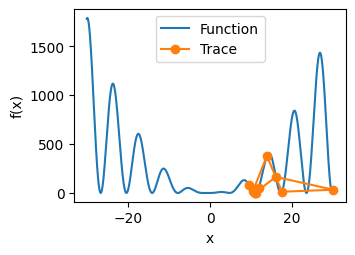

In [6]:
def f(x):
    return x**2 * (1 + np.sin(x))

def f_prime(x):
    return 2*x*(1 + np.sin(x)) + x**2 * np.cos(x)


def sgd(eta=0.1, f_grad=None):
    x = torch.tensor(10.0)
    results = [x]
    for i in range(10):
        g = f_grad(x)
        g += torch.normal(0.0, 1, (1,)).item()
        eta = eta * lr()
        x -= eta * g
        results.append(float(x))
    print(f'epoch 10, x: {x:f}')
    return results

def constant_lr():
    return 0.8

eta = 0.1
lr = constant_lr  # 常数学习速度
# lr = exponential_lr
show_trace(sgd(eta, f_prime),f)